# `gf_cutoffs()` — Test Notebook

Tests cover:
- Basic usage (explicit expression vs. auto-detect from fill)
- All five distribution-part functions
- Distribution shapes: normal, skewed, bimodal, binomial, small n, large n
- Stacking multiple cutoff sets
- Labels
- Edge cases

In [224]:
library(coursekata)
library(ggformula)
library(ggplot2)
library(gridExtra)

source("../gf_cutoffs.R")

# Shared sampling distribution (normal, large n)
set.seed(42)
sdob1 <- do(1000) * b1(shuffle(Tip) ~ Condition, data = TipExperiment)
obs_b1 <- b1(Tip ~ Condition, data = TipExperiment)

cat("obs_b1 =", obs_b1, "\n")
favstats(~ b1, data = sdob1)

obs_b1 = 6.045455 


,min,Q1,median,Q3,max,mean,sd,n,missing
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
,-9.5,-2.25,0.04545455,2.318182,10.31818,0.06181818,3.433428,1000,0


---
## 1. Basic usage — explicit expression

Simplest case: no fill on histogram, expression passed directly.

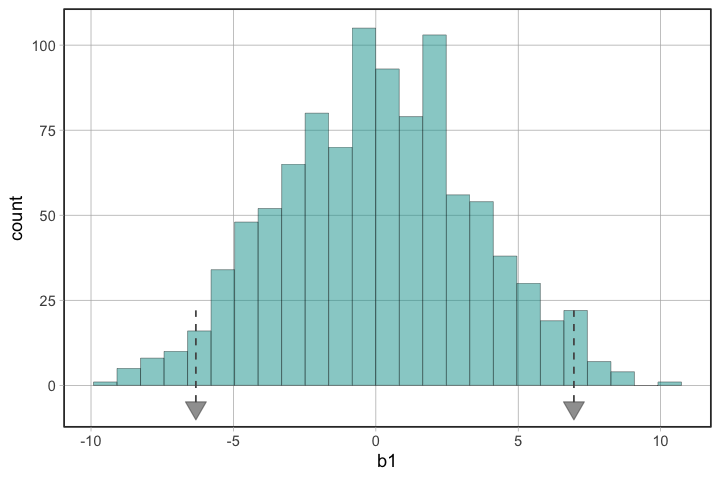

In [225]:
# Test 1: explicit middle(), no fill
gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(middle(b1, .95))

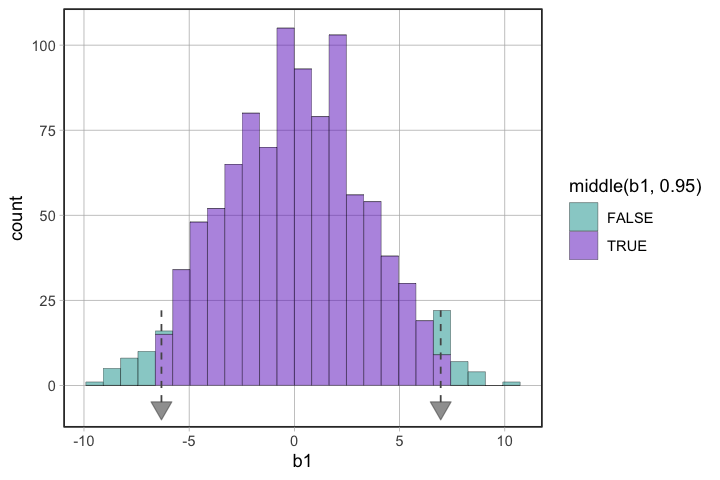

In [226]:
# Test 2: auto-detect from fill (no expression passed)
gf_histogram(~ b1, data = sdob1, fill = ~ middle(b1, .95)) %>%
  gf_cutoffs()

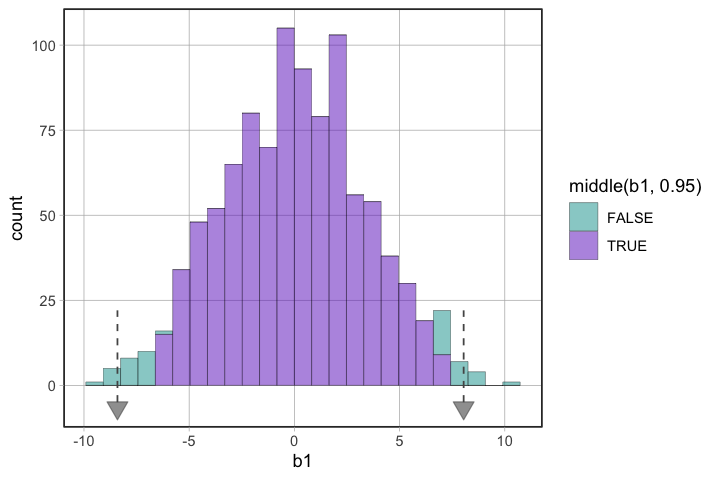

In [227]:
# Test 3: explicit expression overrides fill (different proportions)
# Fill colors middle 95%; cutoffs mark middle 99% — markers should be further out
gf_histogram(~ b1, data = sdob1, fill = ~ middle(b1, .95)) %>%
  gf_cutoffs(middle(b1, .99))

---
## 2. All five distribution-part functions

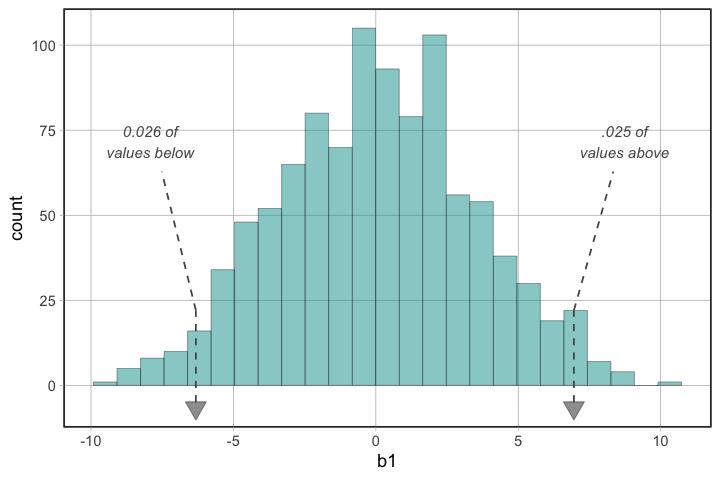

In [228]:
# Test 4: middle() — two cutoffs, symmetric
gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(middle(b1, .95), labels = TRUE)

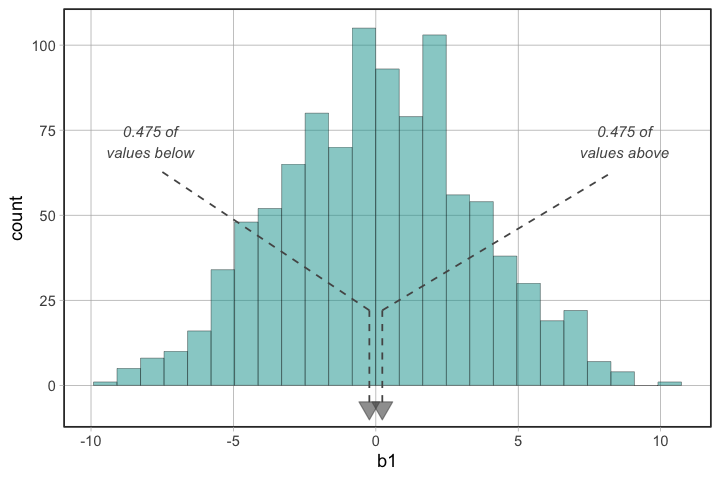

In [229]:
# Test 5: tails() — same boundaries as middle(.95), different framing
# Should produce identical marker positions as Test 4
gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(tails(b1, .05), labels = TRUE)

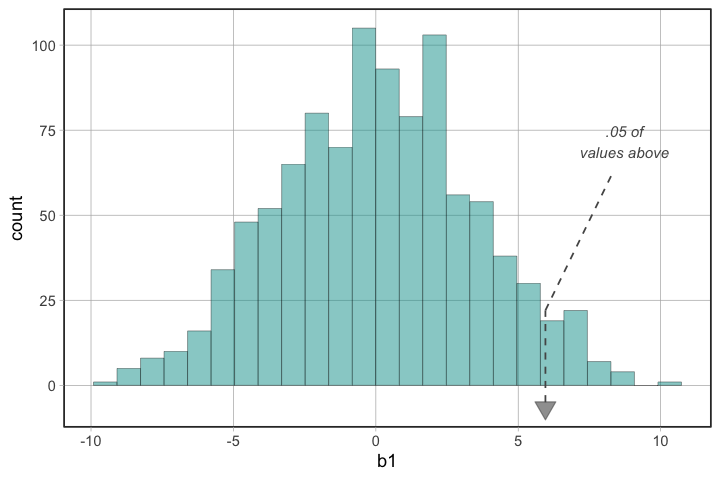

In [230]:
# Test 6: upper() — one cutoff, right tail only
gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(upper(b1, .05), labels = TRUE)

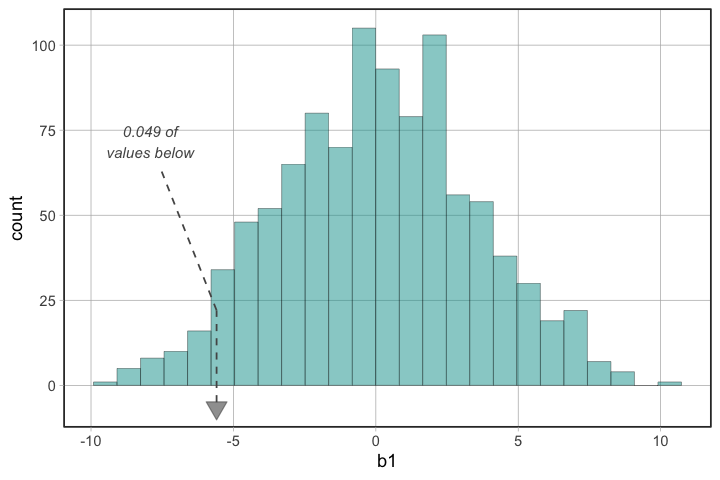

In [231]:
# Test 7: lower() — one cutoff, left tail only
gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(lower(b1, .05), labels = TRUE)

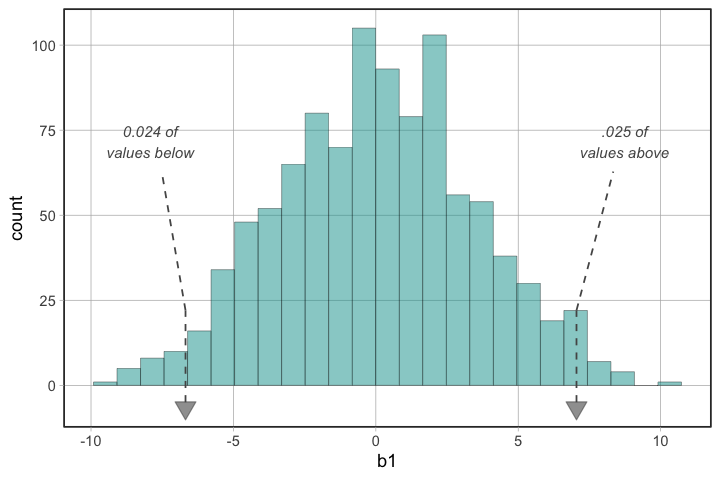

In [232]:
# Test 8: outer() — same as tails(), both tails
# outer(b1, .05) ≡ tails(b1, .95) — should match Test 5 marker positions
gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(outer(b1, .05), labels = TRUE)

---
## 3. Stacking multiple cutoff sets

The flagship feature: show multiple alpha levels simultaneously.

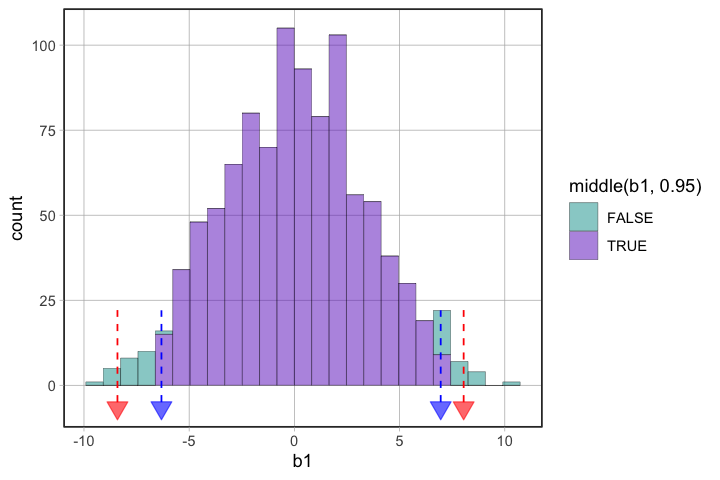

In [233]:
# Test 9: two alpha levels — α=.05 (blue) and α=.01 (red)
# Expect: blue markers further in, red markers further out
gf_histogram(~ b1, data = sdob1, fill = ~ middle(b1, .95)) %>%
  gf_cutoffs(middle(b1, .95), color = "blue") %>%
  gf_cutoffs(middle(b1, .99), color = "red")

Warning message:
"gf_cutoffs: labels = TRUE on multiple stacked calls will overlap. Use labels = TRUE on only one gf_cutoffs() call at a time."


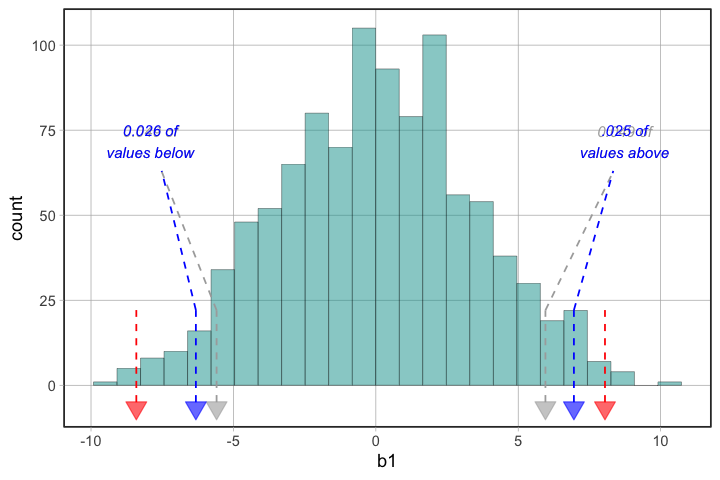

In [234]:
# Test 10: three alpha levels — labels only on the innermost cutoff
# (adding labels = TRUE to multiple stacked calls causes overlap and a warning)
gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(middle(b1, .90), color = "#aaaaaa", labels = TRUE) %>%  # labels here only
  gf_cutoffs(middle(b1, .95), color = "blue", labels = TRUE) %>%
  gf_cutoffs(middle(b1, .99), color = "red")

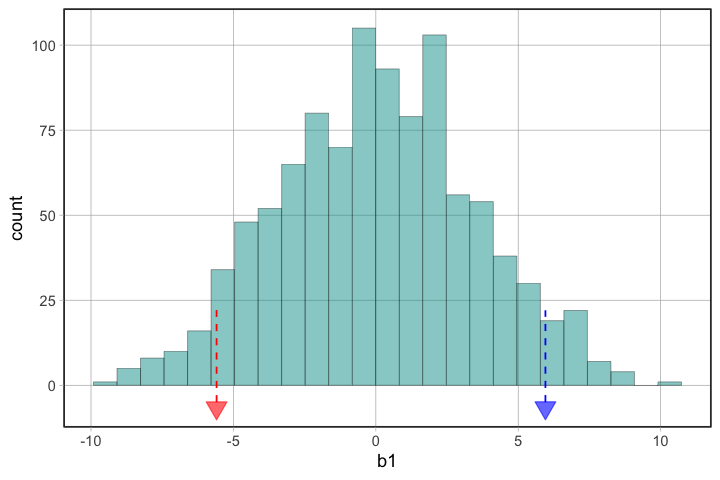

In [235]:
# Test 11: upper and lower one-tailed cutoffs stacked (compare directions)
gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(upper(b1, .05), color = "blue") %>%
  gf_cutoffs(lower(b1, .05), color = "red")

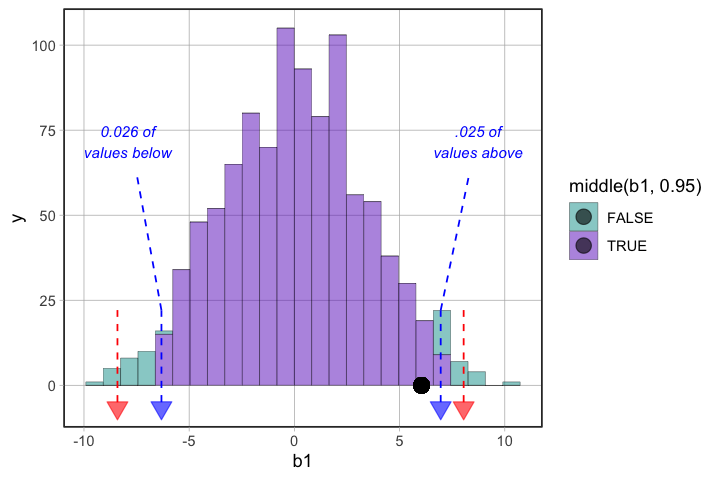

In [236]:
# Test 12: fill + stacked cutoffs + observed b1
gf_histogram(~ b1, data = sdob1, fill = ~ middle(b1, .95)) %>%
  gf_cutoffs(middle(b1, .95), color = "blue", labels = TRUE) %>%
  gf_cutoffs(middle(b1, .99), color = "red") %>%
  gf_point(0 ~ obs_b1, color = "black", size = 4)

---
## 4. Distribution shapes

### 4a. Normal distributions

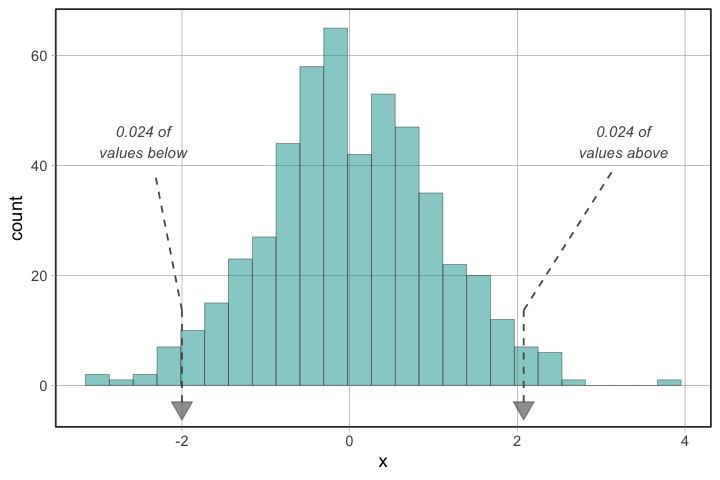

In [237]:
# Test 13: tight normal (small SD)
set.seed(1)
d_tight <- data.frame(x = rnorm(500, mean = 0, sd = 1))

gf_histogram(~ x, data = d_tight) %>%
  gf_cutoffs(middle(x, .95), labels = TRUE)

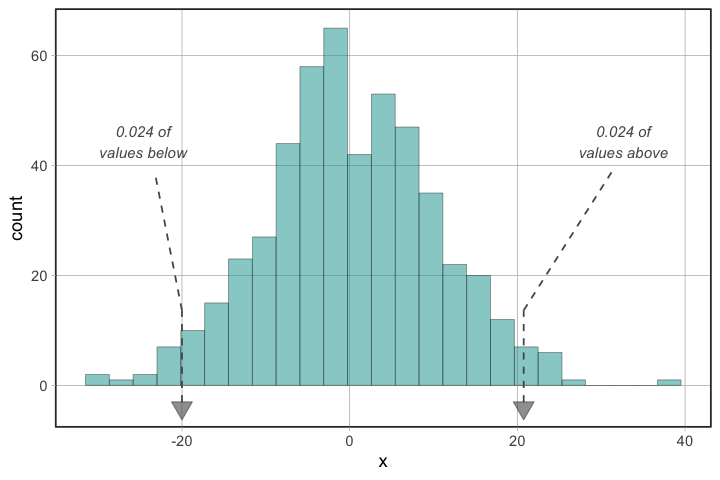

In [238]:
# Test 14: wide normal (large SD)
set.seed(1)
d_wide <- data.frame(x = rnorm(500, mean = 0, sd = 10))

gf_histogram(~ x, data = d_wide) %>%
  gf_cutoffs(middle(x, .95), labels = TRUE)

### 4b. Small n — does cutoff detection hold up?

Warning message:
"gf_cutoffs: no cutoff positions found <e2><80><94> n may be too small to place markers. Returning plot unchanged."


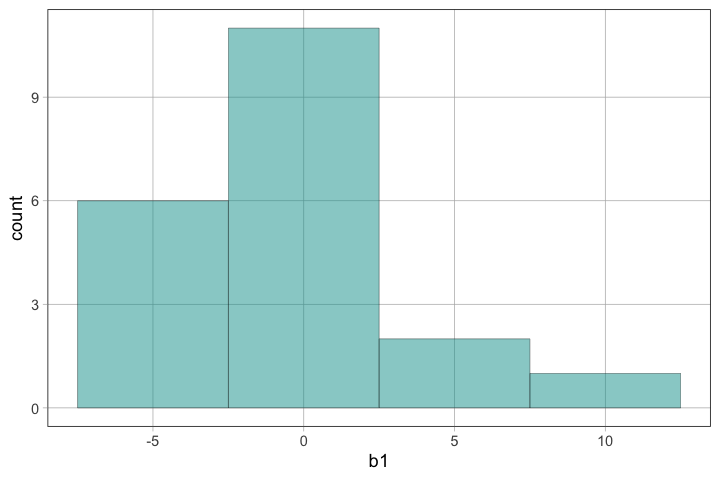

In [239]:
# Test 15: small n = 20
set.seed(2)
sdob1_small <- do(20) * b1(shuffle(Tip) ~ Condition, data = TipExperiment)

gf_histogram(~ b1, data = sdob1_small, binwidth = 5) %>%
  gf_cutoffs(middle(b1, .95), labels = TRUE)

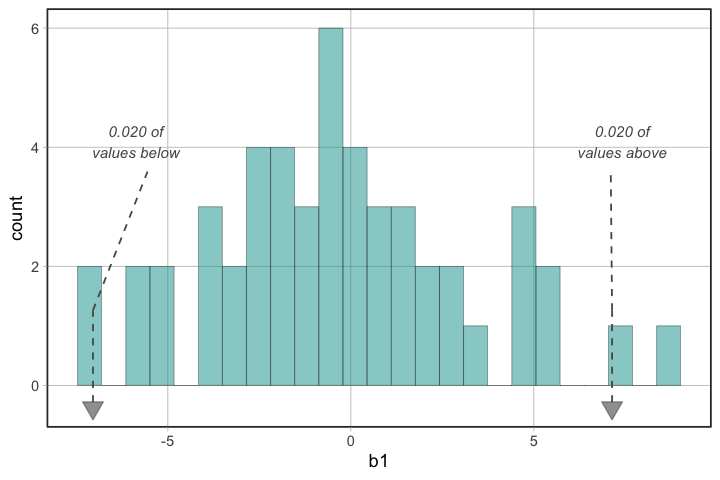

In [240]:
# Test 16: small n = 50
set.seed(2)
sdob1_50 <- do(50) * b1(shuffle(Tip) ~ Condition, data = TipExperiment)

gf_histogram(~ b1, data = sdob1_50) %>%
  gf_cutoffs(middle(b1, .95), labels = TRUE)

### 4c. Large n

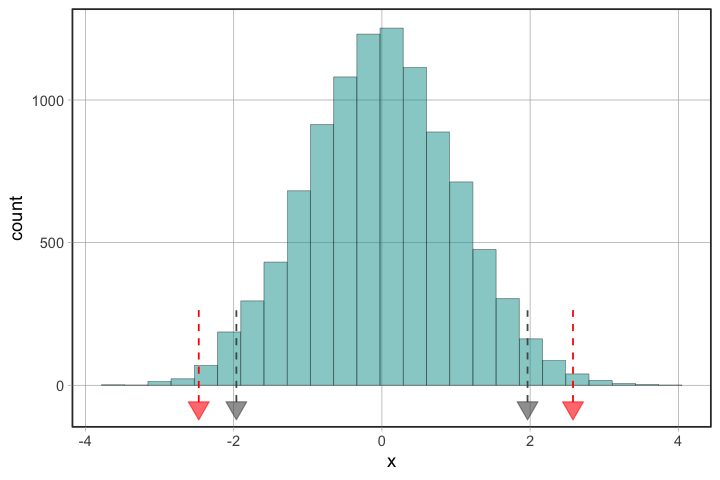

In [241]:
# Test 17: large n = 10000
set.seed(3)
d_large <- data.frame(x = rnorm(10000))

gf_histogram(~ x, data = d_large) %>%
  gf_cutoffs(middle(x, .95)) %>%
  gf_cutoffs(middle(x, .99), color = "red")

### 4d. Skewed distributions

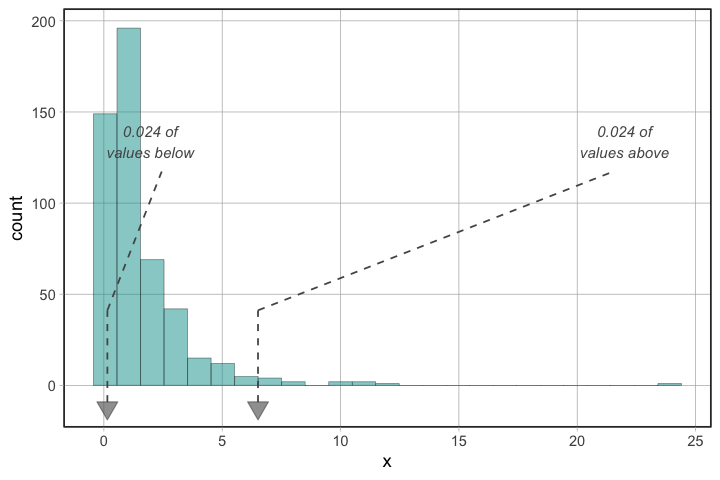

In [242]:
# Test 18: right-skewed (log-normal)
set.seed(4)
d_skew_right <- data.frame(x = rlnorm(500, meanlog = 0, sdlog = 1))

gf_histogram(~ x, data = d_skew_right) %>%
  gf_cutoffs(middle(x, .95), labels = TRUE)

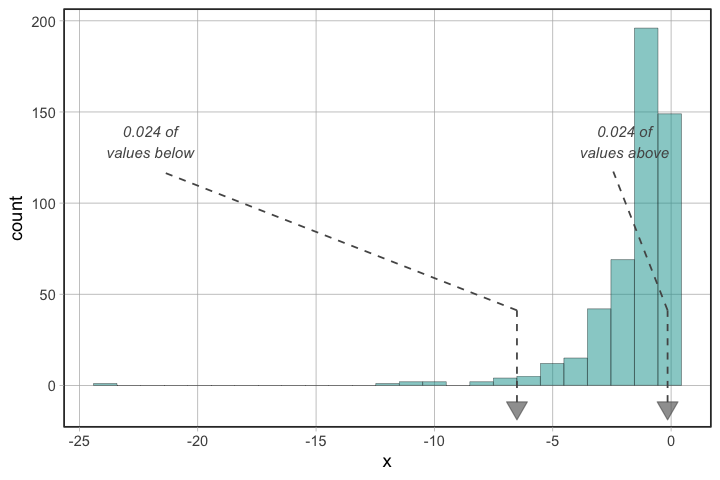

In [243]:
# Test 19: left-skewed (negate log-normal)
set.seed(4)
d_skew_left <- data.frame(x = -rlnorm(500, meanlog = 0, sdlog = 1))

gf_histogram(~ x, data = d_skew_left) %>%
  gf_cutoffs(middle(x, .95), labels = TRUE)

Lower cutoff (2.5th pctile): 0.1488653 
Upper cutoff (97.5th pctile): 6.281482 


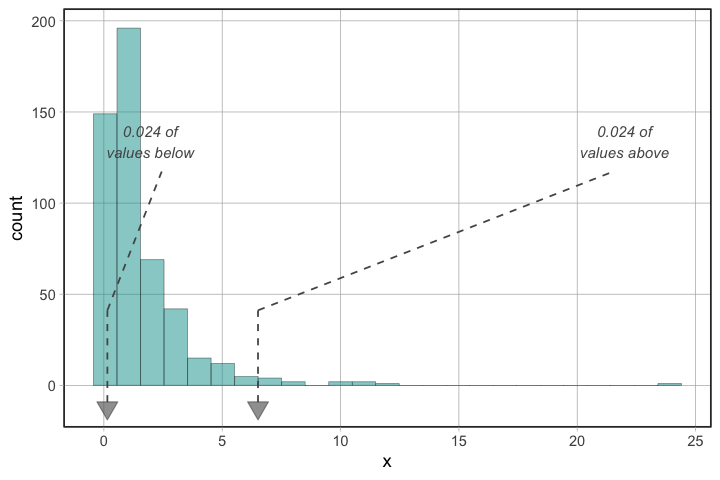

In [244]:
# Test 20: skewed — check that lower and upper cutoffs are NOT symmetric
# Lower cutoff should be much closer to center than upper cutoff
set.seed(4)
d_skew_right <- data.frame(x = rlnorm(500))

p <- gf_histogram(~ x, data = d_skew_right) %>%
  gf_cutoffs(middle(x, .95), labels = TRUE)
p

# Print the cutoff values to verify asymmetry
x_vals <- d_skew_right$x
cat("Lower cutoff (2.5th pctile):", quantile(x_vals, 0.025), "\n")
cat("Upper cutoff (97.5th pctile):", quantile(x_vals, 0.975), "\n")

### 4e. Binomial distributions

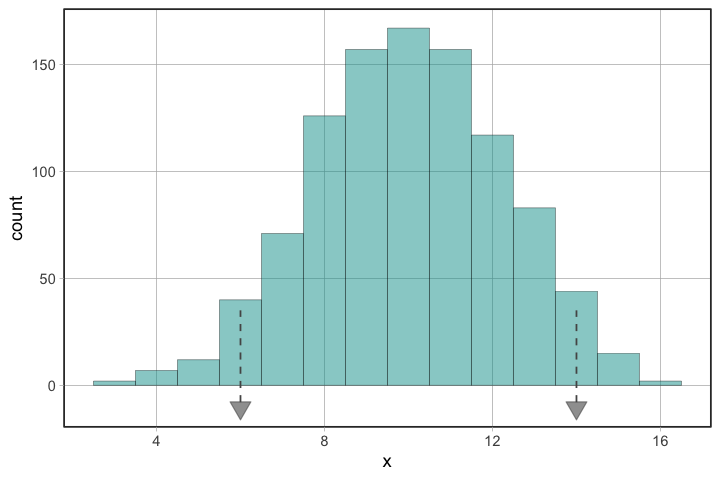

In [245]:
# Test 21: binomial (symmetric, discrete)
set.seed(5)
d_binom <- data.frame(x = rbinom(1000, size = 20, prob = 0.5))

gf_histogram(~ x, data = d_binom, binwidth = 1) %>%
  gf_cutoffs(middle(x, .95))

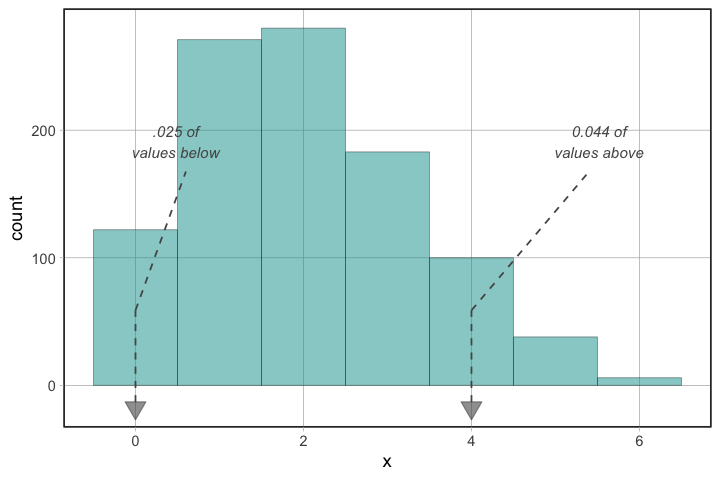

In [246]:
# Test 22: binomial (skewed, p = 0.1)
set.seed(5)
d_binom_skew <- data.frame(x = rbinom(1000, size = 20, prob = 0.1))

gf_histogram(~ x, data = d_binom_skew, binwidth = 1) %>%
  gf_cutoffs(middle(x, .95), labels = TRUE)

### 4f. Bimodal distribution

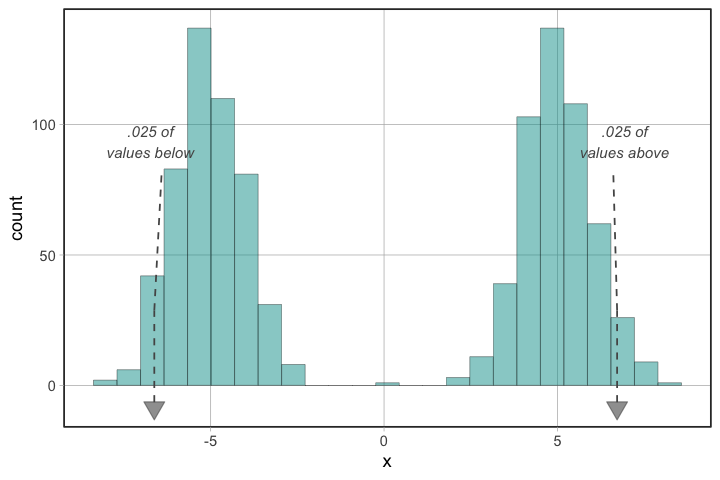

In [247]:
# Test 23: bimodal — cutoffs should still reflect the empirical quantiles,
# even though the distribution shape is unusual
set.seed(6)
d_bimodal <- data.frame(x = c(rnorm(500, -5, 1), rnorm(500, 5, 1)))

gf_histogram(~ x, data = d_bimodal) %>%
  gf_cutoffs(middle(x, .95), labels = TRUE)

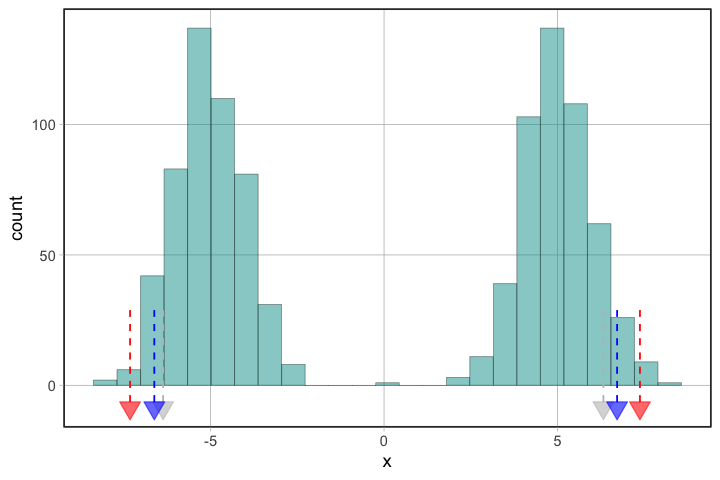

In [248]:
# Test 24: bimodal — stacked cutoffs to show both alpha levels
set.seed(6)
d_bimodal <- data.frame(x = c(rnorm(500, -5, 1), rnorm(500, 5, 1)))

gf_histogram(~ x, data = d_bimodal) %>%
  gf_cutoffs(middle(x, .90), color = "gray") %>%
  gf_cutoffs(middle(x, .95), color = "blue") %>%
  gf_cutoffs(middle(x, .99), color = "red")

---
## 5. Confidence interval context (resample)

Same syntax, different inferential setup.

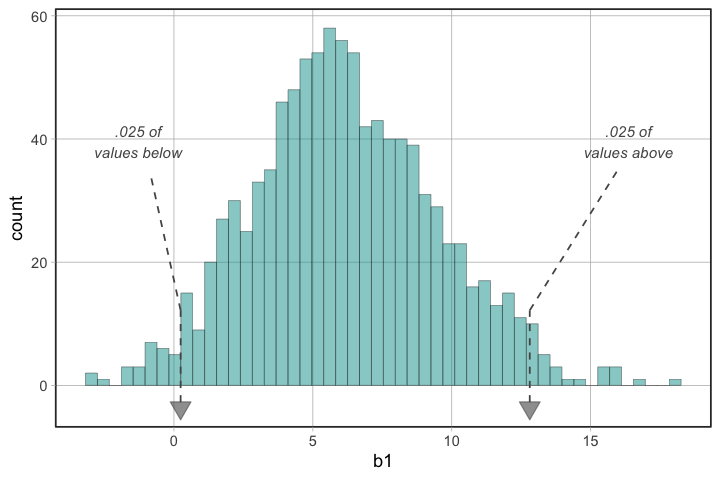

In [249]:
# Test 25: bootstrap CI with middle()
set.seed(42)
sdob1_boot <- do(1000) * b1(Tip ~ Condition, data = resample(TipExperiment))

gf_histogram(~ b1, data = sdob1_boot, bins = 50) %>%
  gf_cutoffs(middle(b1, .95), labels = TRUE)

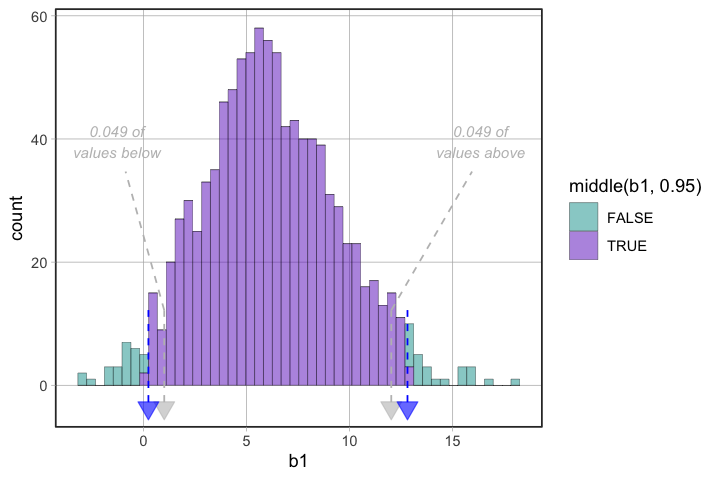

In [250]:
# Test 26: 90% and 95% CI stacked
set.seed(42)
sdob1_boot <- do(1000) * b1(Tip ~ Condition, data = resample(TipExperiment))

gf_histogram(~ b1, data = sdob1_boot, fill = ~ middle(b1, .95), bins = 50) %>%
  gf_cutoffs(middle(b1, .90), color = "gray", labels = TRUE) %>%
  gf_cutoffs(middle(b1, .95), color = "blue")

---
## 6. Edge cases and error handling

In [251]:
# Test 27: wrong variable name in expression — should error clearly
tryCatch(
  gf_histogram(~ b1, data = sdob1) %>%
    gf_cutoffs(middle(x, .95)),   # x doesn't exist in sdob1
  error = function(e) cat("Expected error:\n", conditionMessage(e), "\n")
)

Expected error:
 object 'x' not found 


In [252]:
# Test 28: no expression and no distribution-part fill — should error clearly
tryCatch(
  gf_histogram(~ b1, data = sdob1) %>%
    gf_cutoffs(),
  error = function(e) cat("Expected error:\n", conditionMessage(e), "\n")
)

Expected error:
 gf_cutoffs: no expression given and no distribution-part fill found.
Either pass an expression: gf_cutoffs(middle(b1, .95))
Or set fill = ~middle(b1, .95) in gf_histogram(). 


In [253]:
# Test 29: non-distribution-part fill (plain color) + no expression — should error clearly
tryCatch(
  gf_histogram(~ b1, data = sdob1, fill = "steelblue") %>%
    gf_cutoffs(),
  error = function(e) cat("Expected error:\n", conditionMessage(e), "\n")
)

Expected error:
 gf_cutoffs: no expression given and no distribution-part fill found.
Either pass an expression: gf_cutoffs(middle(b1, .95))
Or set fill = ~middle(b1, .95) in gf_histogram(). 


Warning message:
"gf_cutoffs: no cutoff positions found <e2><80><94> n may be too small to place markers. Returning plot unchanged."


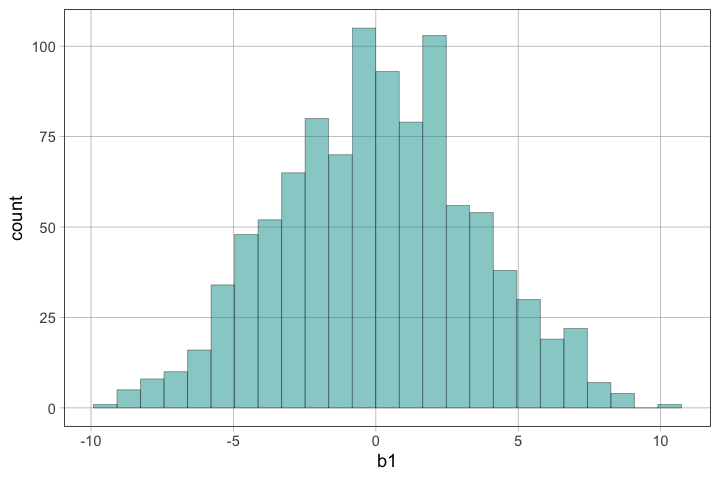

In [254]:
# Test 30: very extreme proportion (.999) — cutoffs very far out, might be at data boundary
gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(middle(b1, .999), labels = TRUE)

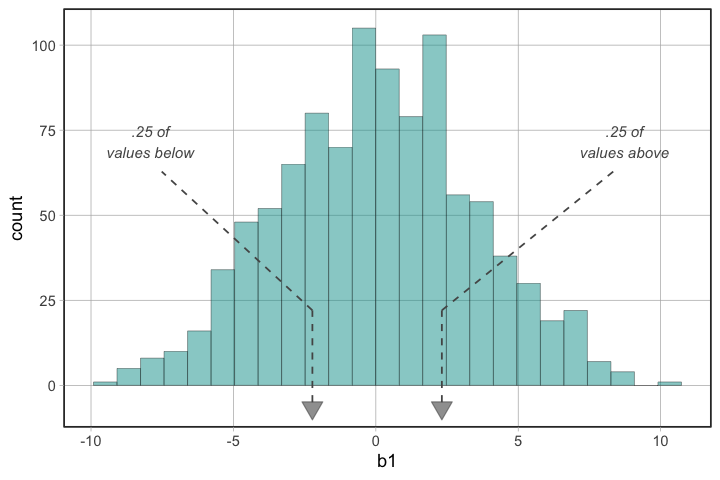

In [255]:
# Test 31: middle(.50) — two cutoffs at 25th and 75th percentiles
# Labels should say ".25 of values below" and ".25 of values above"
gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(middle(b1, .50), labels = TRUE)

In [256]:
# Test 32: used on a scatter plot — should error with clear message
tryCatch(
  gf_point(Thumb ~ Height, data = Fingers) %>%
    gf_cutoffs(middle(Thumb, .95)),
  error = function(e) cat("Expected error:\n", conditionMessage(e), "\n")
)

Expected error:
 gf_cutoffs: plot has a y aesthetic <e2><80><94> gf_cutoffs() only works with gf_histogram(), not scatter plots or other two-variable plots. 


Expected warning:
 gf_cutoffs: labels = TRUE on multiple stacked calls will overlap. Use labels = TRUE on only one gf_cutoffs() call at a time. 


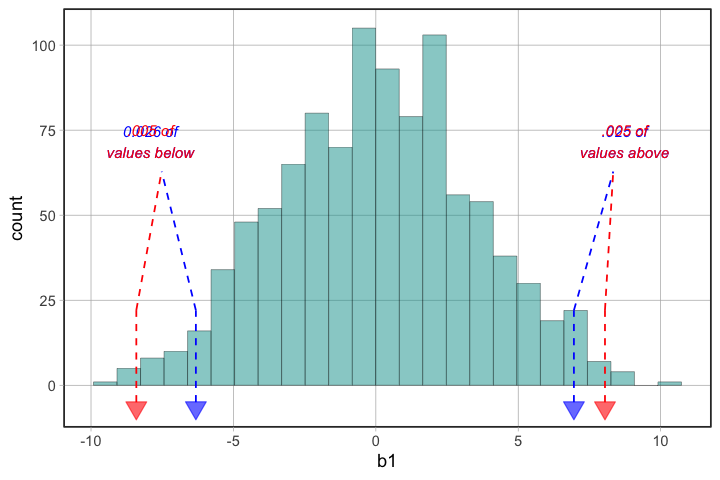

In [257]:
# Test 32b: stacked labels should warn (labels overlap)
withCallingHandlers(
  gf_histogram(~ b1, data = sdob1) %>%
    gf_cutoffs(middle(b1, .95), color = "blue",  labels = TRUE) %>%
    gf_cutoffs(middle(b1, .99), color = "red",   labels = TRUE),
  warning = function(w) {
    cat("Expected warning:\n", conditionMessage(w), "\n")
    invokeRestart("muffleWarning")
  }
)

### 6b. Tie-breaking: `upper(.5)` and `lower(.5)`

When exactly half the values are in the TRUE region, both sides have equal proportion.
Tie-breaking rule: `upper(.5)` → label the upper side (".50 of values above");
`lower(.5)` → label the lower side (".50 of values below").

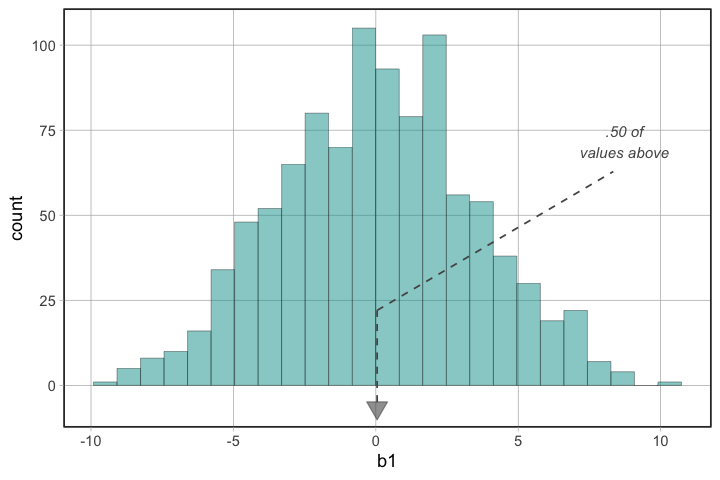

In [258]:
# Test 33b: upper(.5) — one cutoff at median; should label ".50 of values above"
gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(upper(b1, .5), labels = TRUE)

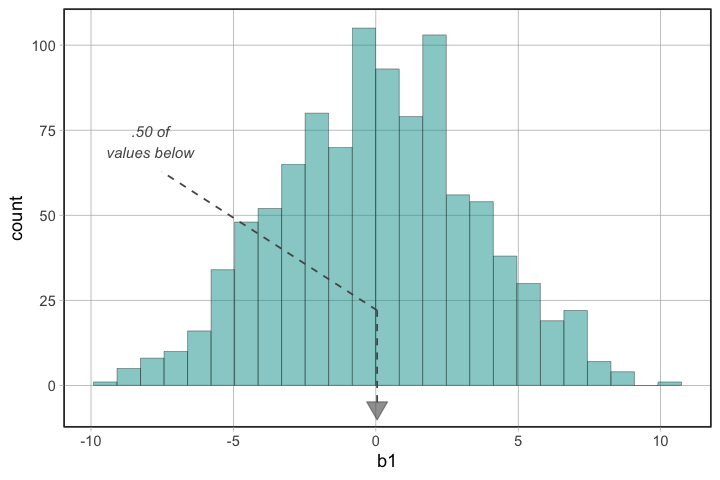

In [259]:
# Test 33c: lower(.5) — one cutoff at median; should label ".50 of values below"
gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(lower(b1, .5), labels = TRUE)

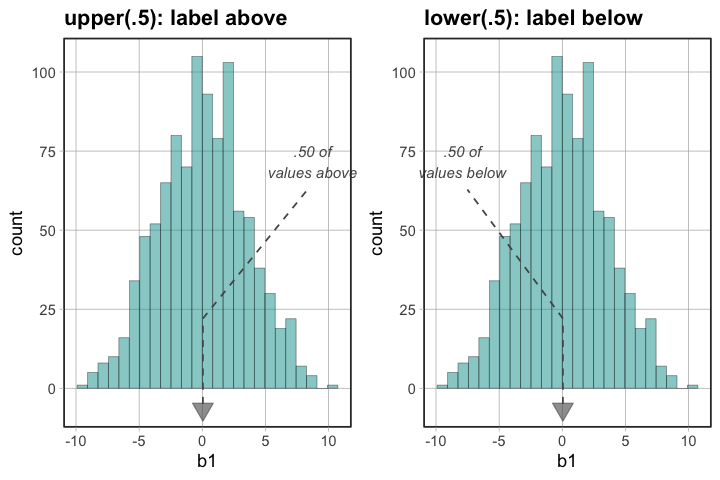

In [ ]:
# Test 33d: sanity check — upper(.5) and lower(.5) should produce the same
# cutoff x-position (both at the median), just with labels on opposite sides
p_upper <- gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(upper(b1, .5), labels = TRUE) +
  labs(title = "upper(.5): label above")

p_lower <- gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(lower(b1, .5), labels = TRUE) +
  labs(title = "lower(.5): label below")

options(repr.plot.width = 12, repr.plot.height = 4)
grid.arrange(p_upper, p_lower, ncol = 2)
options(repr.plot.width = 6, repr.plot.height = 4)

---
## 7. Comparison: `gf_cutoffs()` vs. `show_cutoffs()`

These pairs should produce visually identical marker positions.

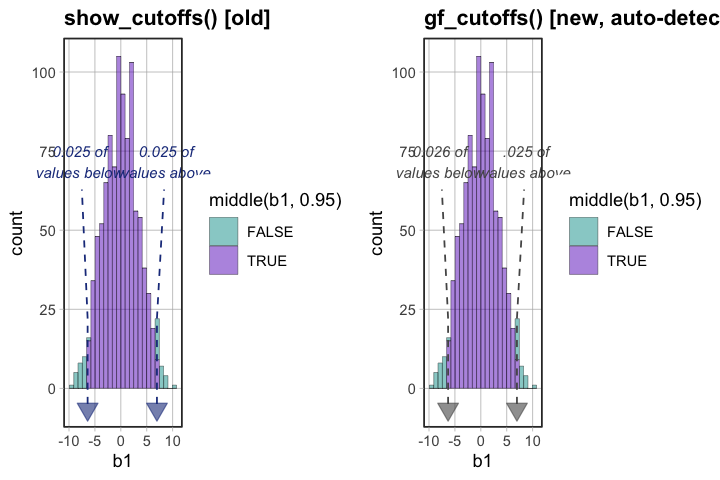

In [ ]:
# Test 33: side-by-side comparison — middle(.95)
p_old <- gf_histogram(~ b1, data = sdob1, fill = ~ middle(b1, .95)) %>%
  show_cutoffs(labels = TRUE) +
  labs(title = "show_cutoffs() [old]")

p_new <- gf_histogram(~ b1, data = sdob1, fill = ~ middle(b1, .95)) %>%
  gf_cutoffs(labels = TRUE) +
  labs(title = "gf_cutoffs() [new, auto-detect]")

options(repr.plot.width = 12, repr.plot.height = 4)
grid.arrange(p_old, p_new, ncol = 2)
options(repr.plot.width = 6, repr.plot.height = 4)

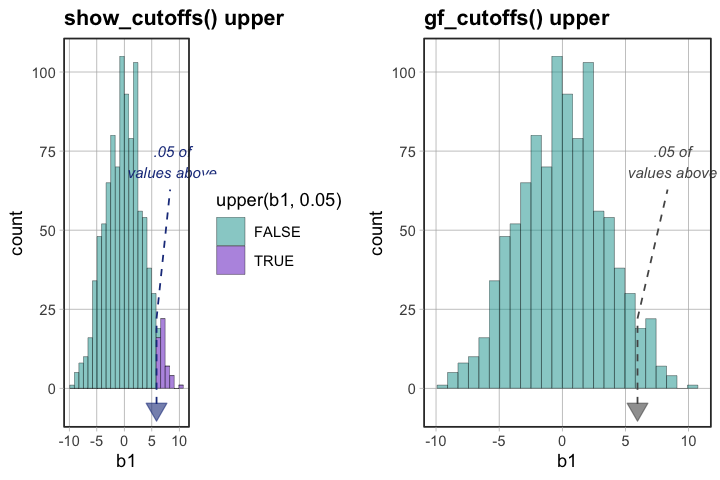

In [262]:
# Test 34: side-by-side — upper(.05)
p_old <- gf_histogram(~ b1, data = sdob1, fill = ~ upper(b1, .05)) %>%
  show_cutoffs(labels = TRUE) +
  labs(title = "show_cutoffs() upper")

p_new <- gf_histogram(~ b1, data = sdob1) %>%
  gf_cutoffs(upper(b1, .05), labels = TRUE) +
  labs(title = "gf_cutoffs() upper")

grid.arrange(p_old, p_new, ncol = 2)